In [1]:
import warnings
warnings. filterwarnings('ignore')

import pathlib
from datetime import datetime, timedelta
from functools import partial

import numpy as np
import pandas as pd
import xarray as xr
import torch

from matplotlib import pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.ops import MLP
from torchvision.utils import _log_api_usage_once
from lightning.pytorch import LightningModule, LightningDataModule, Trainer, seed_everything
from lightning.pytorch.callbacks import TQDMProgressBar
from lightning.pytorch.loggers import CSVLogger
from tqdm import tqdm

In [2]:
data_path = pathlib.Path("../data/cloudsat-goes-paired/")
files = sorted(list(data_path.glob("*.nc")))


In [3]:
def get_sza_and_azi(date: datetime, lat: float, lon: float) -> tuple[float, float]:
    """Get the solar zenith angle at a specific time/lat/lon

    Parameters
    ----------
    date : datetime | array of datetime like
        Dates of the points
    lat : float
        Latitudes
    lon : float
        Longitudes

    Returns
    -------
    sza: float
        The solar zenith angle in degrees, where 0 is directly above, 90 is on 
        the horizon and 180 is directly below
    saa: float
        The solar azimuth angle in degrees, clockwise from North
    """
    try:
        date = pd.DatetimeIndex(date)
    except TypeError:
        date = pd.DatetimeIndex([date])
    day_of_year = date.dayofyear.to_numpy()
    hour_of_day = (
        date.hour + date.minute / 60 + date.second / 60 /60
    ).to_numpy()

    # calculate approx time equation as angle for 365 day year
    equation_of_time_approx = 2.0 * np.pi * day_of_year / 365.0

    # calculate the solar declination for the given day
    # the declination varies due to the fact that the earth rotation axis
    # is not perpendicular to the ecliptic plane
    solar_declination = (
        0.006918
        - 0.399912 * np.cos(equation_of_time_approx)
        - 0.006758 * np.cos(2.0 * equation_of_time_approx)
        - 0.002697 * np.cos(3.0 * equation_of_time_approx)
        + 0.070257 * np.sin(equation_of_time_approx)
        + 0.000907 * np.sin(2.0 * equation_of_time_approx)
        + 0.001480 * np.sin(3.0 * equation_of_time_approx)
    )

    # equation of time, used to compensate for the earth's elliptical orbit
    # around the sun and its axial tilt when calculating solar time
    # eqt is the correction in hours
    equation_of_time = 2.0 * np.pi * day_of_year / 366.0
    equation_of_time = (
        0.0072 * np.cos(equation_of_time)
        - 0.0528 * np.cos(2.0 * equation_of_time)
        - 0.0012 * np.cos(3.0 * equation_of_time)
        - 0.1229 * np.sin(equation_of_time)
        - 0.1565 * np.sin(2.0 * equation_of_time)
        - 0.0041 * np.sin(3.0 * equation_of_time)
    )

    # calculate the solar zenith angle
    omega = np.radians(
        (360.0 / 24.0) * (hour_of_day + lon / 15.0 + equation_of_time - 12.0)
    )
    sunh = np.sin(solar_declination) * np.sin(np.radians(lat)) + np.cos(
        solar_declination
    ) * np.cos(np.radians(lat)) * np.cos(omega)

    solar_elevation = np.arcsin(np.clip(sunh, -1, 1))
    solar_zenith_angle = np.pi / 2.0 - solar_elevation

    # Solar azimuth added by yaswant
    azimuth = (
        np.sin(solar_declination) * np.cos(np.radians(lat))
        - np.cos(solar_declination) * np.sin(np.radians(lat)) * np.cos(omega)
    ) / np.cos(np.pi / 2.0 - solar_zenith_angle)

    solar_azimuth_angle = np.arccos(np.clip(azimuth, -1, 1))

    return np.degrees(solar_zenith_angle), np.degrees(solar_azimuth_angle)

In [4]:
class GeoCloudsatDataset(Dataset):
    def __init__(self, files):
        super().__init__()
        self.files = files
    
    def __len__(self):
        return len(self.files)

    def load_image_and_geoloc(self, idx):
        with xr.open_datatree(self.files[idx]) as dt:
            image_input = dt.geo_patch.data.fillna(0)
            image_input[:6] = image_input[:6] / 100
            image_input[6:] = image_input[6:] / 140 - 180
            image_input = np.clip(image_input, 0, 1).values.astype(np.float32)

            time_of_day = (dt.geo_patch.t.values - dt.geo_patch.t.values.astype("datetime64[D]")) / np.timedelta64(1, "D").astype("timedelta64[ns]")
            time_of_year = (dt.geo_patch.t.values - dt.geo_patch.t.values.astype("datetime64[Y]")) / np.timedelta64(1, "Y").astype("timedelta64[ns]")
            
            geoloc_input = np.stack([
                dt.geo_patch.longitude, 
                dt.geo_patch.latitude, 
                dt.geo_patch.sat_angle[1], 
                dt.geo_patch.sat_angle[0], 
                dt.geo_patch.solar_angle[1], 
                dt.geo_patch.solar_angle[0], 
                np.full(dt.geo_patch.longitude.shape, time_of_day, np.float32), 
                np.full(dt.geo_patch.longitude.shape, time_of_year, np.float32), 
            ], 0).astype(np.float32)

            cloudsat_offset = (dt.cloudsat_unaligned.Nray.size-256)//2
            cloudsat_unaligned = dt.cloudsat_unaligned.isel(Nray=slice(cloudsat_offset, cloudsat_offset+256))

            target = cloudsat_unaligned.IWC.fillna(0).values.astype(np.float32)
            
            cloudsat_sza, cloudsat_azi = get_sza_and_azi(
                cloudsat_unaligned.Profile_time.values,
                cloudsat_unaligned.Latitude.values, 
                cloudsat_unaligned.Longitude.values,
            )
            
            time_of_day = (cloudsat_unaligned.Profile_time.values - cloudsat_unaligned.Profile_time.values.astype("datetime64[D]")) / np.timedelta64(1, "D").astype("timedelta64[ns]")
            time_of_year = (cloudsat_unaligned.Profile_time.values - cloudsat_unaligned.Profile_time.astype("datetime64[Y]")) / np.timedelta64(1, "Y").astype("timedelta64[ns]")
            
            geoloc_output = np.stack([
                cloudsat_unaligned.Longitude, 
                cloudsat_unaligned.Latitude, 
                np.full(cloudsat_unaligned.Longitude.shape, 0, np.float32), # 0 degree sat angle for all
                np.full(cloudsat_unaligned.Longitude.shape, 0, np.float32), # 0 degree sat angle for all
                cloudsat_azi, # need to calc solar angles
                cloudsat_sza, # need to calc solar angles
                np.full(cloudsat_unaligned.Longitude.shape, time_of_day, np.float32), 
                np.full(cloudsat_unaligned.Longitude.shape, time_of_year, np.float32), 
            ], 0).astype(np.float32)
            
        return image_input, geoloc_input, target, geoloc_output
    
    def __getitem__(self, idx):
        return self.load_image_and_geoloc(idx)

class GeoCloudsatDataloader(LightningDataModule):
    def __init__(
        self, 
        batch_size, 
        files, 
        num_workers=0, 
    ):
        super().__init__()
        self.batch_size = batch_size
        self.num_workers = num_workers

        # Get list of files for each split
        self.train_dataset = GeoCloudsatDataset(files[:int(len(files)*0.7)])
        self.val_dataset = GeoCloudsatDataset(files[int(len(files)*0.75):int(len(files)*0.85)])
        self.test_dataset = GeoCloudsatDataset(files[int(len(files)*0.9):])

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset, 
            batch_size=self.batch_size, 
            shuffle=True,
            pin_memory=True, 
            num_workers=self.num_workers, 
        )
    
    def val_dataloader(self):
        return DataLoader(
            self.val_dataset, 
            batch_size=self.batch_size, 
            shuffle=False,
            pin_memory=True, 
            num_workers=self.num_workers, 
        )
    
    def test_dataloader(self):
        return DataLoader(
            self.test_dataset, 
            batch_size=self.batch_size, 
            shuffle=False,
            pin_memory=True, 
            num_workers=self.num_workers, 
        )

In [5]:
class GeoPositionalEncoding(torch.nn.Module):
    def __init__(
        self,
        patch_size, 
        hidden_dim, 
        harmonics=1, 
    ):
        super().__init__()
        self.harmonics = harmonics
        self.pool = torch.nn.AdaptiveAvgPool2d(patch_size)
        self.input_dim = 13 * self.harmonics
        self.hidden_dim = hidden_dim
        self.num_steps = (hidden_dim // 13) + 1

        self.two_pi = 2 * torch.pi
        self.pi = torch.pi
        self.half_pi = 0.5 * torch.pi

    def calc_2_angle(self, theta):
        theta = theta % self.two_pi
        return (
            torch.sin(torch.deg2rad(theta)), 
            torch.cos(torch.deg2rad(theta)), 
        )

    def calc_3_angle(self, theta, phi):
        theta = theta % self.two_pi
        phi = (phi + self.half_pi) % self.pi - self.half_pi
        return (
            torch.sin(theta), 
            torch.cos(theta), 
            torch.sin(phi), 
        )

    def calc_angles(self, x):
        angles = (
            self.calc_3_angle(torch.deg2rad(x[:,0]), torch.deg2rad(x[:,1]))
            + self.calc_3_angle(torch.deg2rad(x[:,2]), torch.deg2rad(x[:,3]))
            + self.calc_3_angle(torch.deg2rad(x[:,4]), torch.deg2rad(x[:,5]))
            + self.calc_2_angle(x[:,6] * self.two_pi)
            + self.calc_2_angle(x[:,7] * self.two_pi)
        )
        return angles

    def calc_angles_and_harmonics(self, x):
        angles = self.calc_angles(x)

        if self.harmonics>1:
            for i in np.linspace(1, self.harmonics, self.num_steps):
                angles = angles + self.calc_angles(x * i)

        return torch.stack(angles, dim=1)[:,:self.hidden_dim]

    def forward(self, x):
        n, c = x.shape[0], x.shape[1]
        if len(x.shape) == 4:
            x = self.pool(x).reshape(n, c, -1)
        else:
            x = x.reshape(n, c, -1)

        x = self.calc_angles_and_harmonics(x)

        return x.permute(0,2,1)

        # x = x.permute(0,2,1).reshape(-1, self.input_dim)

        # return self.mlp(x).reshape(n, -1, self.hidden_dim)
        

In [6]:
class GeoPositionalEncoding(torch.nn.Module):
    def __init__(
        self,
        patch_size, 
        hidden_dim, 
        harmonics=1, 
    ):
        super().__init__()
        self.harmonics = harmonics
        self.pool = torch.nn.AdaptiveAvgPool2d(patch_size)
        self.input_dim = 13 * self.harmonics
        self.hidden_dim = hidden_dim
        self.mlp = MLP(
            self.input_dim, 
            [hidden_dim, hidden_dim, hidden_dim], 
            norm_layer=torch.nn.LayerNorm, 
            activation_layer=torch.nn.LeakyReLU, 
        )

        self.two_pi = 2 * torch.pi
        self.pi = torch.pi
        self.half_pi = 0.5 * torch.pi

    def calc_2_angle(self, theta):
        theta = theta % self.two_pi
        return (
            torch.sin(torch.deg2rad(theta)), 
            torch.cos(torch.deg2rad(theta)), 
        )

    def calc_3_angle(self, theta, phi):
        theta = theta % self.two_pi
        phi = (phi + self.half_pi) % self.pi - self.half_pi
        return (
            torch.sin(theta), 
            torch.cos(theta), 
            torch.sin(phi), 
        )

    def calc_angles(self, x):
        angles = (
            self.calc_3_angle(torch.deg2rad(x[:,0]), torch.deg2rad(x[:,1]))
            + self.calc_3_angle(torch.deg2rad(x[:,2]), torch.deg2rad(x[:,3]))
            + self.calc_3_angle(torch.deg2rad(x[:,4]), torch.deg2rad(x[:,5]))
            + self.calc_2_angle(x[:,6] * self.two_pi)
            + self.calc_2_angle(x[:,7] * self.two_pi)
        )
        return angles

    def calc_angles_and_harmonics(self, x):
        angles = self.calc_angles(x)

        if self.harmonics>1:
            for i in range(1, self.harmonics):
                angles = angles + self.calc_angles(x * i)

        return torch.stack(angles, dim=1)

    def forward(self, x):
        n, c = x.shape[0], x.shape[1]
        if len(x.shape) == 4:
            x = self.pool(x).reshape(n, c, -1)
        else:
            x = x.reshape(n, c, -1)

        x = self.calc_angles_and_harmonics(x)

        x = x.permute(0,2,1).reshape(-1, self.input_dim)

        return self.mlp(x).reshape(n, -1, self.hidden_dim)
        

In [7]:
from collections import OrderedDict
from torchvision.models.vision_transformer import EncoderBlock

class Encoder(torch.nn.Module):
    """Transformer Model Encoder for sequence to sequence translation."""

    def __init__(
        self,
        seq_length: int,
        num_layers: int,
        num_heads: int,
        hidden_dim: int,
        mlp_dim: int,
        dropout: float,
        attention_dropout: float,
        norm_layer: Callable[..., torch.nn.Module] = partial(torch.nn.LayerNorm, eps=1e-6),
    ):
        super().__init__()
        # Note that batch_size is on the first dim because
        # we have batch_first=True in nn.MultiAttention() by default
        self.dropout = torch.nn.Dropout(dropout)
        layers: OrderedDict[str, torch.nn.Module] = OrderedDict()
        for i in range(num_layers):
            layers[f"encoder_layer_{i}"] = EncoderBlock(
                num_heads,
                hidden_dim,
                mlp_dim,
                dropout,
                attention_dropout,
                norm_layer,
            )
        self.layers = torch.nn.Sequential(layers)
        self.ln = norm_layer(hidden_dim)

    def forward(self, input: torch.Tensor):
        torch._assert(input.dim() == 3, f"Expected (batch_size, seq_length, hidden_dim) got {input.shape}")
        return self.ln(self.layers(self.dropout(input)))

class CloudsatTransformer(LightningModule):
    """
    A Transformer model to reconstruct CloudSat observations
    """
    def __init__(
        self,
        image_size: int,
        image_channels: int,
        geoloc_channels: int, 
        output_channels: int,
        patch_size: int,
        encoder_layers: int,
        decoder_layers: int, 
        num_heads: int,
        hidden_dim: int,
        mlp_dim: int,
        dropout: float = 0.0,
        attention_dropout: float = 0.0,
        num_classes: int = 1000,
        representation_size: Optional[int] = None,
        norm_layer = partial(torch.nn.LayerNorm, eps=1e-6),
        learning_rate: float = 1.5e-4,
        loss_function = torch.nn.MSELoss(),
    ):
        super().__init__()
        _log_api_usage_once(self)
        torch._assert(image_size % patch_size == 0, "Input shape indivisible by patch size!")
        self.image_size = image_size
        self.image_channels = image_channels
        self.geoloc_channels = geoloc_channels
        self.output_channels = output_channels
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size)**2
        self.hidden_dim = hidden_dim
        self.mlp_dim = mlp_dim
        self.attention_dropout = attention_dropout
        self.dropout = dropout
        self.num_classes = num_classes
        self.representation_size = representation_size
        self.learning_rate = learning_rate
        self.loss_function = loss_function
        self.mask_ratio = 0.75

        # Add a class token
        self.class_token = torch.nn.Parameter(torch.zeros(1, 1, hidden_dim))
        self.mask_token = torch.nn.Parameter(torch.zeros(1, 1, hidden_dim))
        self.seq_length = self.num_patches + 1

        self.encoder = Encoder(
            self.seq_length,
            encoder_layers,
            num_heads,
            hidden_dim,
            mlp_dim,
            dropout,
            attention_dropout,
            norm_layer,
        )

        self.decoder = Encoder(
            self.seq_length, 
            decoder_layers, 
            num_heads, 
            hidden_dim,
            mlp_dim,
            dropout,
            attention_dropout,
            norm_layer,
        )

        self.image_encoder = image_conv = torch.nn.Sequential(
            torch.nn.Conv2d(
                self.image_channels, 
                self.hidden_dim, 
                kernel_size=self.patch_size, 
                stride=self.patch_size
            ), 
            torch.nn.LeakyReLU()
        )

        self.geopos_encoder = GeoPositionalEncoding(
            self.patch_size, 
            self.hidden_dim, 
            # harmonics=90, 
        )

        self.output_head = MLP(
            self.hidden_dim, 
            [self.hidden_dim, self.hidden_dim, self.hidden_dim, self.output_channels], 
            activation_layer=torch.nn.LeakyReLU, 
        )

        self.decoder_pred = torch.nn.Linear(self.hidden_dim, patch_size**2 * self.image_channels, bias=True) # decoder to patch

        # initialize nn.Linear and nn.LayerNorm
        self.apply(self._init_weights)

    def initialize_weights(self):
        # initialization
        # initialize (and freeze) pos_embed by sin-cos embedding
        # pos_embed = get_2d_sincos_pos_embed(self.pos_embed.shape[-1], int(self.patch_embed.num_patches**.5), cls_token=True)
        # self.pos_embed.data.copy_(torch.from_numpy(pos_embed).float().unsqueeze(0))

        # decoder_pos_embed = get_2d_sincos_pos_embed(self.decoder_pos_embed.shape[-1], int(self.patch_embed.num_patches**.5), cls_token=True)
        # self.decoder_pos_embed.data.copy_(torch.from_numpy(decoder_pos_embed).float().unsqueeze(0))

        

        
        
        # initialize nn.Linear and nn.LayerNorm
        self.apply(self._init_weights)

    def _init_weights(self, m):
        # initialize patch_embed like nn.Linear (instead of nn.Conv2d)
        # w = self.image_encoder.proj.weight.data
        # torch.nn.init.xavier_uniform_(w.view([w.shape[0], -1]))
        
        # timm's trunc_normal_(std=.02) is effectively normal_(std=0.02) as cutoff is too big (2.)
        torch.nn.init.normal_(self.class_token, std=.02)
        torch.nn.init.normal_(self.mask_token, std=.02)
        
        if isinstance(m, torch.nn.Linear):
            # we use xavier_uniform following official JAX ViT:
            torch.nn.init.xavier_uniform_(m.weight)
            if isinstance(m, torch.nn.Linear) and m.bias is not None:
                torch.nn.init.constant_(m.bias, 0)
        elif isinstance(m, torch.nn.LayerNorm):
            torch.nn.init.constant_(m.bias, 0)
            torch.nn.init.constant_(m.weight, 1.0)

    def encode_image(self, x):
        n = x.shape[0]
        return self.image_encoder(x).reshape(n, self.hidden_dim, -1).permute(0, 2, 1)
        
    def encode_geopos(self, geopos):
        return self.geopos_encoder(geopos)

    def forward_encode(self, x, geopos):
        n = x.shape[0]
        x = self.encode_image(x) + self.encode_geopos(geopos)
        x = torch.cat(
            [
                self.class_token.expand(n, -1, -1),
                x,
            ],
            1
        )

        return self.encoder(x)

    def forward_decode(self, x, geopos):
        n_batch, n_target = geopos.shape[0], geopos.shape[-1]
        
        geopos_x = self.mask_token.expand(n_batch, -1, -1) + self.encode_geopos(geopos)
        
        x = torch.cat([x[:,:1], geopos_x, x[:,1:]], 1)

        x = self.decoder(x)
    
        x = x[:, 1:n_target+1]

        return x

    def forward_output(self, x):
        n_batch = x.shape[0]

        x = self.output_head(x.reshape(-1, self.hidden_dim))

        return x.reshape(n_batch, -1, self.output_channels)

    def random_masking(self, x, mask_ratio):
        """
        Perform per-sample random masking by per-sample shuffling.
        Per-sample shuffling is done by argsort random noise.
        x: [N, L, D], sequence
        """
        N, L, D = x.shape  # batch, length, dim
        len_keep = int(L * (1 - mask_ratio))
        
        noise = torch.rand(N, L, device=x.device)  # noise in [0, 1]
        
        # sort noise for each sample
        ids_shuffle = torch.argsort(noise, dim=1)  # ascend: small is keep, large is remove
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        # keep the first subset
        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))

        # generate the binary mask: 0 is keep, 1 is remove
        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0
        # unshuffle to get the binary mask
        mask = torch.gather(mask, dim=1, index=ids_restore)

        return x_masked, mask, ids_restore
    

    def forward_encoder(self, x, geopos, mask_ratio):
        x = self.encode_image(x) + self.encode_geopos(geopos)

        # masking: length -> length * mask_ratio
        x, mask, ids_restore = self.random_masking(x, mask_ratio)

        # append cls token
        cls_token = self.class_token
        cls_tokens = cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        # apply Transformer blocks
        x = self.encoder(x)

        return x, mask, ids_restore

    def forward_decoder(self, x, geopos, ids_restore):
        # # embed tokens
        # x = self.decoder_embed(x)

        # append mask tokens to sequence
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] + 1 - x.shape[1], 1)
        x_ = torch.cat([x[:, 1:, :], mask_tokens], dim=1)  # no cls token
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[2]))  # unshuffle
        x_ = x_ + self.encode_geopos(geopos)
        x = torch.cat([x[:, :1, :], x_], dim=1)  # append cls token

        # # add pos embed
        # x = torch.cat([
        #     x[:,:1],
        #     x[:,1:] + self.encode_geopos(geopos)
        # ], dim=1)

        # apply Transformer blocks
        x = self.decoder(x)

        # predictor projection
        x = self.decoder_pred(x)

        # remove cls token
        x = x[:, 1:, :]

        return x

    def forward(self, x, image_geopos):
        x, mask, ids_restore = self.forward_encoder(x, image_geopos, self.mask_ratio)

        x = self.forward_decoder(x, image_geopos, ids_restore)

        # print(x.shape)

        # x = self.forward_output(x)

        # Reshape to original image
        # n, l, c*p**2 -> n, c, h, w

        n, l, clp = x.shape

        patches_per_dim = self.image_size // self.patch_size

        x = x.reshape(n, patches_per_dim, patches_per_dim, self.patch_size, self.patch_size, self.image_channels) # n, h/p, w/p, p, p, c

        x = x.permute(0, 5, 1, 3, 2, 4) # -> n, c, h/p, p, w/p, p

        x = x.reshape(n, self.image_channels, self.image_size, self.image_size)

        return x

    def compute_loss(self, batch):
        image, geopos_in, target, geopos_out = batch
        # forward pass
        predictions = self.forward(image, geopos_in)
        # calculate loss
        loss = self.loss_function(predictions, image)
        return loss

    def training_step(self, batch, batch_idx):
        loss = self.compute_loss(batch)
        # log training loss
        self.log(
            "train_loss", loss, on_step=True, on_epoch=True, logger=True, prog_bar=True
        )
        return loss
    
    def validation_step(self, batch, batch_idx):
        loss = self.compute_loss(batch)
        # log validation loss
        self.log(
            "val_loss", loss, on_step=True, on_epoch=True, logger=True, prog_bar=True
        )
        return loss

    def test_step(self, batch, batch_idx):
        loss = self.compute_loss(batch)
        # log test loss
        self.log(
            "test_loss", loss, on_step=True, on_epoch=True, logger=True, prog_bar=True
        )
        return loss
        
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": ReduceLROnPlateau(optimizer),
                "patience": 10,
                "interval": "epoch",
                "monitor": "val_loss",
                "frequency": 1,
            },
        }

In [8]:
class LitProgressBar(TQDMProgressBar):
    def init_validation_tqdm(self):
        bar = tqdm(            
            disable=True,            
        )
        return bar

# Add a logger for metrics and checkpoints
csv_logger = CSVLogger(
    save_dir='',
    name='logs'
)

In [9]:
_ = seed_everything(42)

dl = GeoCloudsatDataloader(4, files[:500])

model = CloudsatTransformer(
    image_size=256,
    image_channels=16,
    geoloc_channels=13,
    output_channels=125,
    patch_size=16,
    encoder_layers=8,
    decoder_layers=4,
    num_heads=8,
    hidden_dim=1024,
    mlp_dim=2024,
    
)

# Initialize the trainer
trainer = Trainer(
    max_epochs=10,
    callbacks=[LitProgressBar()],
    logger=csv_logger,
    accelerator="auto",
)

trainer.fit(model, dl)

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name           | Type                  | Params | Mode  | FLOPs
-------------------------------------------------------------------------
0 | loss_function  | MSELoss               | 0      | train | 0    
1 | encoder        | Encoder               | 66.8 M | train | 0    
2 | decoder        | Encoder               | 33.4 M | train | 0    
3 | image_encoder  | Sequential            | 4.2 M  | train | 0    
4 | geopos_encoder | GeoPositionalEncoding | 2.1 M  | train | 0    
5 | output_head    | MLP                   | 3.3 M  | train | 0    
6 | decoder_pred   | Linear                | 4.2 M  | train | 0    
  | other params   | n/a                   | 2.0 K  | n/a   | n/a  
--------------

Epoch 9: 100%|████████| 88/88 [00:29<00:00,  2.96it/s, v_num=33, train_loss_step=0.00437, val_loss_step=0.0114, val_loss_epoch=0.00552, train_loss_epoch=0.00556]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|████████| 88/88 [00:30<00:00,  2.88it/s, v_num=33, train_loss_step=0.00437, val_loss_step=0.0114, val_loss_epoch=0.00552, train_loss_epoch=0.00556]


In [10]:
_ = model.eval()

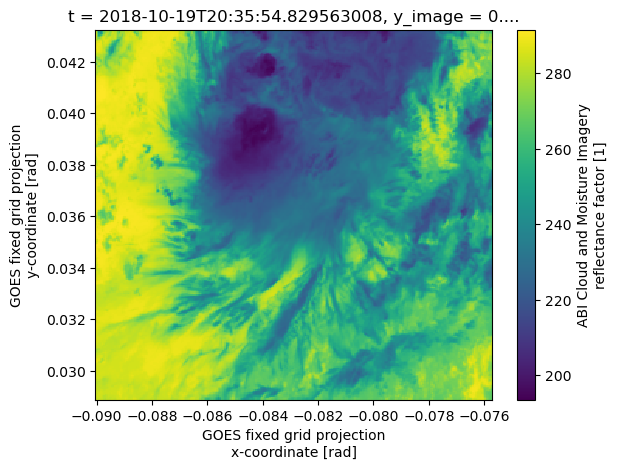

In [11]:
dt = xr.open_datatree(files[300])
image_input = dt.geo_patch.data
image_input[-3].plot()
image_input[:6] = image_input[:6] / 100
image_input[6:] = image_input[6:] / 140 - 180
image_input = np.clip(image_input, 0, 1)
image_input = torch.tensor(image_input.data[np.newaxis])

In [12]:
time_of_day = (dt.geo_patch.t.values - dt.geo_patch.t.values.astype("datetime64[D]")) / np.timedelta64(1, "D").astype("timedelta64[ns]") * 2 * np.pi
time_of_year = (dt.geo_patch.t.values - dt.geo_patch.t.values.astype("datetime64[Y]")) / np.timedelta64(1, "Y").astype("timedelta64[ns]") * 2 * np.pi

geoloc_input = torch.tensor(np.stack([
    dt.geo_patch.longitude, 
    dt.geo_patch.latitude, 
    dt.geo_patch.sat_angle[1], 
    dt.geo_patch.sat_angle[0], 
    dt.geo_patch.solar_angle[1], 
    dt.geo_patch.solar_angle[0], 
    np.full(dt.geo_patch.longitude.shape, time_of_day, np.float32), 
    np.full(dt.geo_patch.longitude.shape, time_of_year, np.float32), 
], 0).astype(np.float32)[np.newaxis])


In [13]:
test = model.forward(image_input, geoloc_input)

In [14]:
test.shape

torch.Size([1, 16, 256, 256])

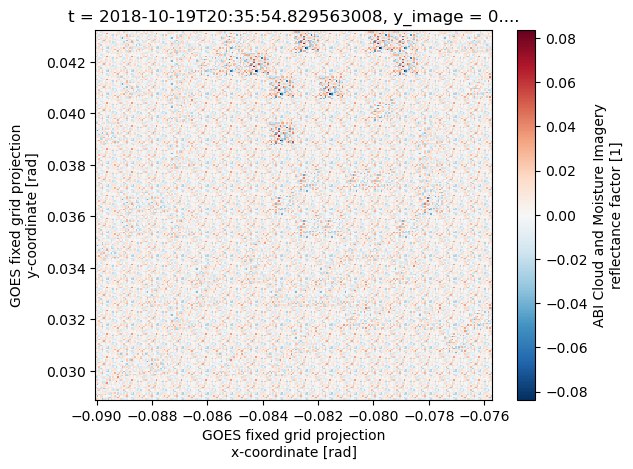

In [15]:
dt.geo_patch.data[-3].copy(data=test[0,-3].detach().numpy()).plot()

In [44]:
cloudsat_offset = (dt.cloudsat_unaligned.Nray.size-256)//2
cloudsat_unaligned = dt.cloudsat_unaligned.isel(Nray=slice(cloudsat_offset, cloudsat_offset+256))

cloudsat_sza, cloudsat_azi = get_sza_and_azi(
    cloudsat_unaligned.Profile_time.values,
    cloudsat_unaligned.Latitude.values, 
    cloudsat_unaligned.Longitude.values,
)

time_of_day = (cloudsat_unaligned.Profile_time.values - cloudsat_unaligned.Profile_time.values.astype("datetime64[D]")) / np.timedelta64(1, "D").astype("timedelta64[ns]") * 2 * np.pi
time_of_year = (cloudsat_unaligned.Profile_time.values - cloudsat_unaligned.Profile_time.astype("datetime64[Y]")) / np.timedelta64(1, "Y").astype("timedelta64[ns]") * 2 * np.pi

geoloc_output = torch.tensor(np.stack([
    cloudsat_unaligned.Longitude, 
    cloudsat_unaligned.Latitude, 
    np.full(cloudsat_unaligned.Longitude.shape, 0, np.float32), # 0 degree sat angle for all
    np.full(cloudsat_unaligned.Longitude.shape, 0, np.float32), # 0 degree sat angle for all
    cloudsat_azi, # need to calc solar angles
    cloudsat_sza, # need to calc solar angles
    np.full(cloudsat_unaligned.Longitude.shape, time_of_day, np.float32), 
    np.full(cloudsat_unaligned.Longitude.shape, time_of_year, np.float32), 
], 0).astype(np.float32)[np.newaxis])

# geoloc_output = torch.tensor(np.stack([
#     np.sin(np.radians(cloudsat_unaligned.Longitude)), 
#     np.cos(np.radians(cloudsat_unaligned.Longitude)), 
#     np.sin(np.radians(cloudsat_unaligned.Latitude)), 
#     np.full(cloudsat_unaligned.Longitude.shape, np.sin(0), np.float32), # 0 degree sat angle for all
#     np.full(cloudsat_unaligned.Longitude.shape, np.cos(0), np.float32), # 0 degree sat angle for all
#     np.full(cloudsat_unaligned.Longitude.shape, np.sin(0), np.float32), # 0 degree sat angle for all
#     np.sin(np.radians(cloudsat_azi)), # need to calc solar angles
#     np.cos(np.radians(cloudsat_azi)), # need to calc solar angles
#     np.sin(np.radians(cloudsat_sza)), # need to calc solar angles
#     np.full(cloudsat_unaligned.Longitude.shape, np.sin(time_of_day), np.float32), 
#     np.full(cloudsat_unaligned.Longitude.shape, np.cos(time_of_day), np.float32), 
#     np.full(cloudsat_unaligned.Longitude.shape, np.sin(time_of_year), np.float32), 
#     np.full(cloudsat_unaligned.Longitude.shape, np.cos(time_of_year), np.float32), 
# ], -1).astype(np.float32)[np.newaxis])


In [45]:
model.geopos_encoder(geoloc_output).shape

torch.Size([1, 256, 1024])

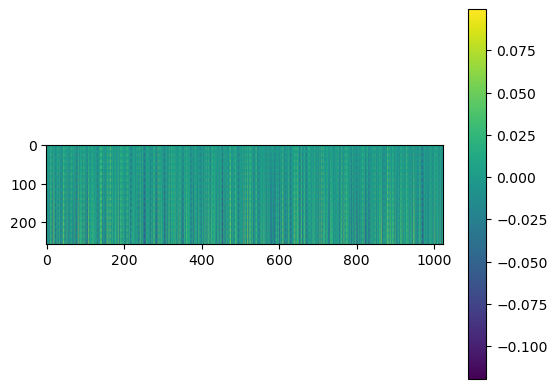

In [32]:
pos = model.geopos_encoder(geoloc_input).detach().numpy()[0]
plt.imshow(pos - pos[:1])
plt.colorbar()

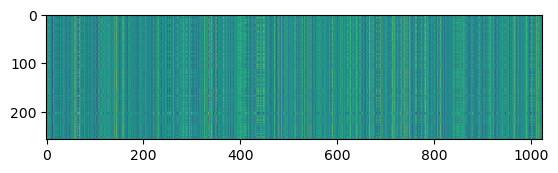

In [18]:
plt.imshow(model.forward_encoder(image_input, geoloc_input, 0)[0].detach().numpy()[0])

In [20]:
x, mask, ids_restore = model.forward_encoder(image_input, geoloc_input, 0)

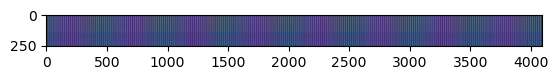

In [24]:
plt.imshow(model.forward_decoder(x, geoloc_input, ids_restore).detach().numpy()[0])

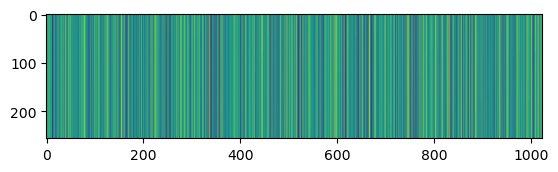

In [20]:
plt.imshow(model.forward_decode(model.forward_encode(image_input, geoloc_input), geoloc_output).detach().numpy()[0])

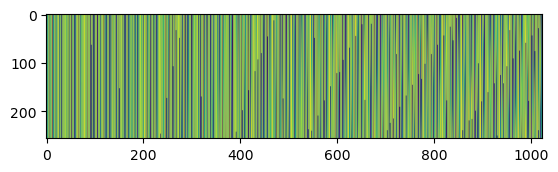

In [21]:
plt.imshow(model.geopos_encoder(geoloc_output).detach().numpy()[0])

In [22]:
model.geopos_encoder(geoloc_output).detach().numpy()[0]

array([[-0.97178155, -0.23588264,  0.18820956, ...,  0.6211826 ,
        -0.9852184 ,  0.10453077],
       [-0.9717729 , -0.23591833,  0.1883758 , ...,  0.6370516 ,
        -0.98416936,  0.10464942],
       [-0.9717643 , -0.23595354,  0.18854217, ...,  0.6526203 ,
        -0.9830798 ,  0.1047596 ],
       ...,
       [-0.9695514 , -0.24488792,  0.23009494, ..., -0.7595654 ,
         0.4160345 ,  0.02374726],
       [-0.96954226, -0.24492398,  0.23025967, ..., -0.7469104 ,
         0.4221753 ,  0.02385802],
       [-0.9695333 , -0.24495958,  0.23042439, ..., -0.7339685 ,
         0.42830363,  0.02397303]], shape=(256, 1024), dtype=float32)

In [23]:
(geoloc_output.numpy().max(1) - geoloc_output.numpy().min(1))

array([[228.65529, 228.67053, 228.68576, 228.69693, 228.71216, 228.7274 ,
        228.74263, 228.75784, 228.77307, 228.78421, 228.79944, 228.81464,
        228.82986, 228.84508, 228.86026, 228.87138, 228.88658, 228.9018 ,
        228.91698, 228.93216, 228.94736, 228.96255, 228.97363, 228.98882,
        229.004  , 229.01917, 229.03433, 229.0495 , 229.06058, 229.07574,
        229.0909 , 229.10606, 229.12122, 229.13638, 229.14742, 229.16255,
        229.1777 , 229.19284, 229.20798, 229.22311, 229.23413, 229.24927,
        229.2644 , 229.27953, 229.29465, 229.30975, 229.32489, 229.33588,
        229.35098, 229.36609, 229.3812 , 229.39629, 229.41139, 229.42236,
        229.43745, 229.45255, 229.46762, 229.48273, 229.4978 , 229.50876,
        229.52383, 229.53891, 229.55396, 229.56905, 229.5841 , 229.59503,
        229.61008, 229.62515, 229.6402 , 229.65524, 229.67029, 229.68533,
        229.69626, 229.71127, 229.72632, 229.74136, 229.75638, 229.77141,
        229.78229, 229.7973 , 229.8123

In [24]:
(geoloc_input.numpy().max(2).max(2) - geoloc_input.numpy().min(2).min(2))

array([[0.02873123, 0.11153919, 0.08546647, 0.0840773 , 0.19021004,
        0.12375039, 0.1298843 , 0.1702789 , 0.09757644, 0.        ,
        0.        , 0.        , 0.        ]], dtype=float32)

In [25]:
geoloc_input.shape

torch.Size([1, 13, 256, 256])